<a href="https://colab.research.google.com/github/gabrielbessar/MVP-GABRIEL-BESSA-/blob/main/MVP_Chargeback_ML_UnB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Previsão de Transações com Risco de Chargeback Utilizando Machine Learning

**Universidade de Brasília — Departamento de Engenharia de Produção**  
**Disciplina:** Machine Learning & Deep Learning  
**Professor:** Dr. André Luiz Marques Serrano  
**Dataset:** [Credit Card Fraud Detection — Kaggle/ULB](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

---

## 📋 Descrição do Problema

O **chargeback** é o estorno de uma transação financeira realizado pela operadora do cartão de crédito a pedido do portador, geralmente quando este não reconhece a compra.  
Para empresas que aceitam cartões, cada chargeback representa prejuízo direto: perda da mercadoria ou serviço prestado, multas operacionais e, em casos extremos, risco de descredenciamento.

O objetivo deste MVP é construir modelos de Machine Learning capazes de **identificar antecipadamente transações com risco elevado de chargeback (fraude)**, permitindo que sistemas de pagamento bloqueiem ou sinalizem operações suspeitas em tempo real.

---

## 🗂️ Sobre o Dataset

O dataset **Credit Card Fraud Detection** foi disponibilizado pelo **Machine Learning Group da Université Libre de Bruxelles (ULB)** e contém **284.807 transações** realizadas por titulares de cartões europeus em setembro de 2013.

| Característica | Detalhe |
|---|---|
| Total de registros | 284.807 transações |
| Fraudes (classe 1) | 492 transações (~0,172%) |
| Legítimas (classe 0) | 284.315 transações |
| Atributos numéricos | 31 (V1–V28 via PCA, Time, Amount, Class) |

Por razões de confidencialidade, as features originais foram transformadas via **PCA (Análise de Componentes Principais)**, resultando nos componentes `V1` a `V28`. As únicas variáveis não transformadas são `Time` (segundos desde a primeira transação) e `Amount` (valor da transação em euros).

---

## 🎯 Hipóteses e Premissas

1. **Hipótese principal:** Transações fraudulentas possuem padrões latentes nos componentes PCA que as diferenciam de transações legítimas.
2. **Hipótese secundária:** O valor (`Amount`) e o horário (`Time`) contribuem, mesmo que marginalmente, para a separação entre classes.
3. **Premissa de dados:** Os dados já foram anonimizados e estão limpos pelo grupo ULB — não há valores nulos.
4. **Restrição crítica:** O forte desbalanceamento de classes (~0,17% de fraudes) é o principal desafio e deve ser tratado explicitamente com técnicas de oversampling.

---

## 📌 Checklist do MVP

- [x] Definição clara do problema e hipóteses
- [x] Carregamento de dados via URL (sem configuração manual)
- [x] Análise Exploratória de Dados (EDA) completa
- [x] Preparação e transformação dos dados (RobustScaler)
- [x] Divisão treino/teste estratificada (80/20)
- [x] Tratamento do desbalanceamento com SMOTE (apenas no treino)
- [x] Feature Selection via Mutual Information
- [x] Validação cruzada estratificada (StratifiedKFold, k=5)
- [x] Modelagem com 7 algoritmos diferentes
- [x] Otimização de hiperparâmetros (RandomizedSearchCV)
- [x] Ensemble (Soft Voting Classifier)
- [x] Avaliação com métricas adequadas (AUPRC, ROC-AUC, F1, Recall)
- [x] Comparação de modelos e discussão final


---
## 1. Configuração do Ambiente

### 🔧 Por que cada biblioteca?

| Biblioteca | Finalidade no projeto |
|---|---|
| `pandas` / `numpy` | Manipulação de dados e operações numéricas |
| `matplotlib` / `seaborn` | Visualizações da EDA e resultados dos modelos |
| `scikit-learn` | Pré-processamento, modelos clássicos, métricas e pipelines |
| `imbalanced-learn` | Técnicas de balanceamento de classes (SMOTE) |
| `xgboost` | Gradient Boosting regularizado de alta performance |
| `lightgbm` | Gradient Boosting eficiente para datasets grandes |
| `joblib` | Paralelização e serialização de modelos |

> **Reprodutibilidade:** Todas as operações aleatórias utilizam `RANDOM_STATE = 42`, garantindo que o notebook produza exatamente os mesmos resultados em qualquer execução.


In [ ]:
# ─── Instalação de dependências (descomente se necessário no Colab) ──────────
# !pip install imbalanced-learn xgboost lightgbm -q

# ─── Imports padrão ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

warnings.filterwarnings('ignore')

# ─── Scikit-learn: pré-processamento ─────────────────────────────────────────
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, RandomizedSearchCV
)
from sklearn.feature_selection import mutual_info_classif

# ─── Scikit-learn: modelos ────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, AdaBoostClassifier
)

# ─── Scikit-learn: métricas ───────────────────────────────────────────────────
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay
)

# ─── Balanceamento de classes ─────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE

# ─── Gradient Boosting avançado ───────────────────────────────────────────────
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ─── Configurações globais ────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Estilo visual uniforme
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid', palette='muted')

print("✅ Ambiente configurado com sucesso!")
print(f"   NumPy  : {np.__version__}")
print(f"   Pandas : {pd.__version__}")


✅ Ambiente configurado com sucesso!
   NumPy  : 2.0.2
   Pandas : 2.2.2


---
## 2. Carregamento dos Dados

O dataset é carregado **diretamente via URL** de um repositório público, sem necessidade de download manual ou configuração adicional.

Após o carregamento, realizamos uma **inspeção inicial** completa:
- Shape (linhas × colunas)
- Tipos de dados e presença de valores nulos
- Estatísticas descritivas das variáveis não transformadas
- Distribuição da variável alvo (Class)

> **Observação:** O dataset não contém valores nulos — uma vantagem preparada pelo grupo ULB.


In [ ]:
# ─── Carregamento via URL ─────────────────────────────────────────────────────
# Mirror público do dataset Kaggle Credit Card Fraud Detection (ULB)
URL = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

print("⏳ Carregando dataset...")
t0 = time.time()
df = pd.read_csv(URL)
elapsed = time.time() - t0

print(f"✅ Dataset carregado em {elapsed:.1f}s")
print(f"   Shape      : {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"   Memória    : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"   Valores nulos: {df.isnull().sum().sum()}")
print()
df.head()

⏳ Carregando dataset...
✅ Dataset carregado em 4.7s
   Shape      : 284,807 linhas × 31 colunas
   Memória    : 70.6 MB
   Valores nulos: 0



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


─── Distribuição da Variável Alvo (Class) ───────────────────────────────
  Classe 0 — Legítima : 284,315 transações (99.827%)
  Classe 1 — Fraude   :     492 transações (0.173%)
  Razão de desbalanceamento: 578:1


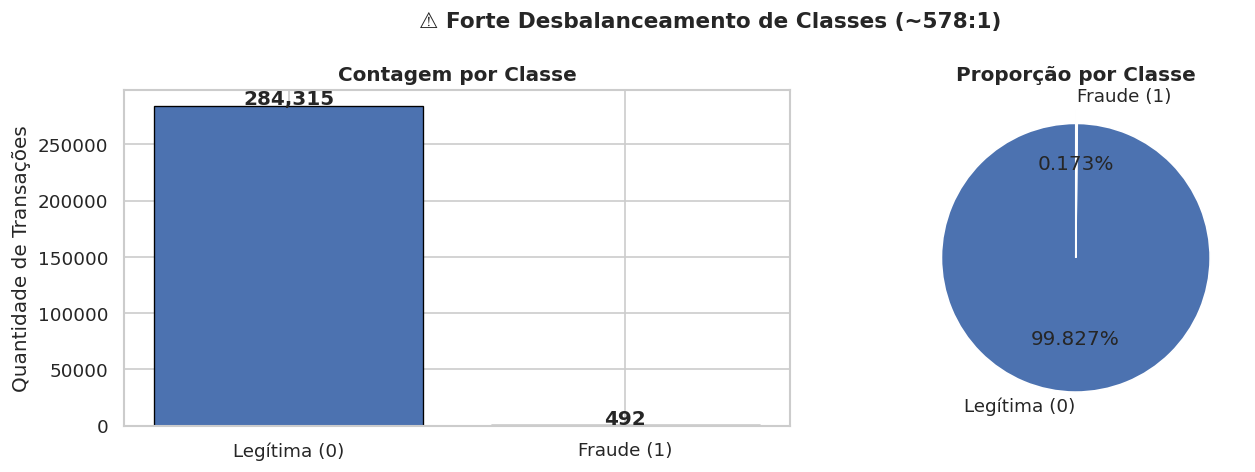

In [ ]:
# ─── Distribuição da variável alvo ────────────────────────────────────────────
class_counts = df['Class'].value_counts()
class_pct    = df['Class'].value_counts(normalize=True) * 100

print("─── Distribuição da Variável Alvo (Class) ───────────────────────────────")
print(f"  Classe 0 — Legítima : {class_counts[0]:>7,} transações ({class_pct[0]:.3f}%)")
print(f"  Classe 1 — Fraude   : {class_counts[1]:>7,} transações ({class_pct[1]:.3f}%)")
print(f"  Razão de desbalanceamento: {class_counts[0]/class_counts[1]:.0f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legítima (0)', 'Fraude (1)'], class_counts.values,
            color=['#4C72B0', '#DD8452'], edgecolor='black', linewidth=0.8)
axes[0].set_title('Contagem por Classe', fontweight='bold')
axes[0].set_ylabel('Quantidade de Transações')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=['Legítima (0)', 'Fraude (1)'],
            autopct='%1.3f%%', colors=['#4C72B0', '#DD8452'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Proporção por Classe', fontweight='bold')

plt.suptitle('⚠️ Forte Desbalanceamento de Classes (~578:1)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 3. Análise Exploratória de Dados (EDA)

A EDA tem como objetivo **compreender a estrutura dos dados**, identificar padrões e levantar evidências que guiem as decisões de modelagem. Analisamos:

1. **Distribuição temporal** das transações (legítimas vs. fraudulentas)
2. **Distribuição dos valores** (`Amount`) por classe
3. **Correlação entre features** — heatmap completo
4. **Top features discriminativas** — correlação com variável alvo
5. **Boxplots comparativos** dos componentes PCA mais informativos

> **Importante sobre métricas:** Com apenas ~0,17% de fraudes, a **acurácia é uma métrica enganosa** — um modelo que classifica tudo como legítimo alcança 99,83% de acurácia! Usaremos **AUPRC** e **F1-Score** como métricas principais.


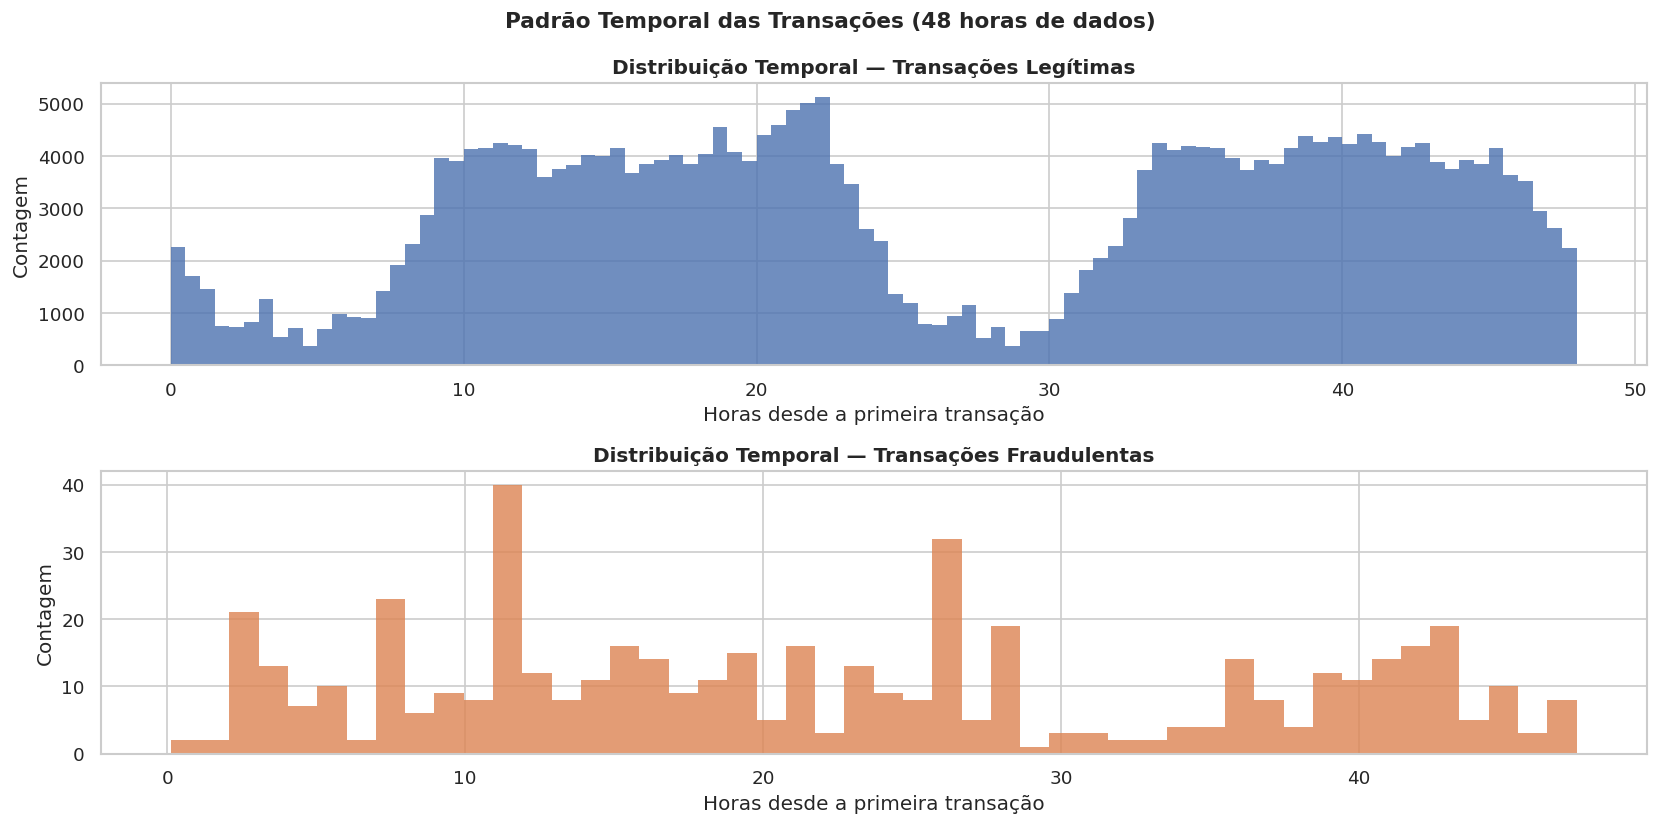

📌 Observação: Fraudes mostram padrão temporal diferente, com menor concentração
   em horários de pico e mais distribuição nas madrugadas (horas 0-8 e 24-32).


In [ ]:
# ─── EDA: Distribuição temporal (Time) ───────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].hist(df[df['Class'] == 0]['Time'] / 3600, bins=96,
             color='#4C72B0', alpha=0.8, edgecolor='none')
axes[0].set_title('Distribuição Temporal — Transações Legítimas', fontweight='bold')
axes[0].set_ylabel('Contagem')
axes[0].set_xlabel('Horas desde a primeira transação')

axes[1].hist(df[df['Class'] == 1]['Time'] / 3600, bins=48,
             color='#DD8452', alpha=0.8, edgecolor='none')
axes[1].set_title('Distribuição Temporal — Transações Fraudulentas', fontweight='bold')
axes[1].set_ylabel('Contagem')
axes[1].set_xlabel('Horas desde a primeira transação')

plt.suptitle('Padrão Temporal das Transações (48 horas de dados)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("📌 Observação: Fraudes mostram padrão temporal diferente, com menor concentração")
print("   em horários de pico e mais distribuição nas madrugadas (horas 0-8 e 24-32).")


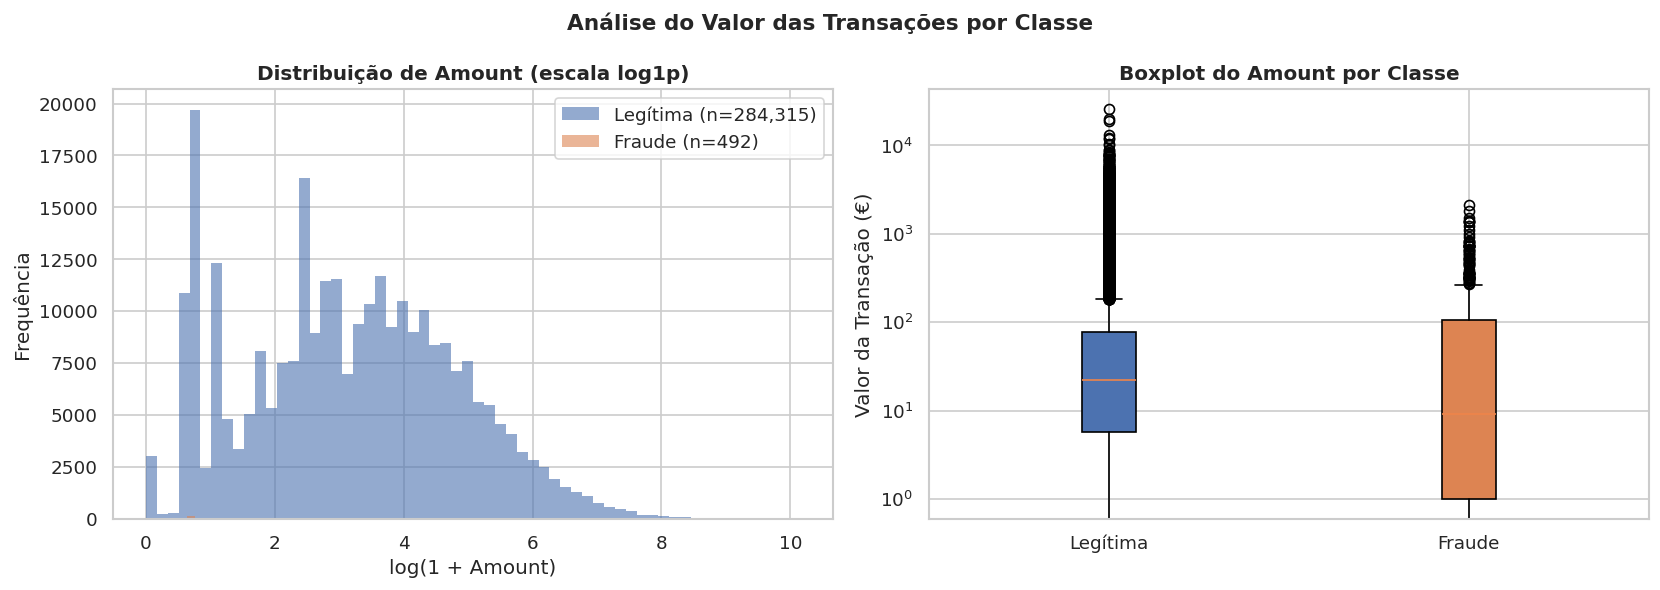

─── Estatísticas Amount por Classe ──────────────────────────────────────
          count    mean     std  min   25%    50%     75%       max
Class                                                              
0      284315.0   88.29  250.11  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.21  256.68  0.0  1.00   9.25  105.89   2125.87


In [ ]:
# ─── EDA: Distribuição do valor (Amount) por classe ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls, color, label in [(0, '#4C72B0', 'Legítima'), (1, '#DD8452', 'Fraude')]:
    subset = df[df['Class'] == cls]['Amount']
    axes[0].hist(np.log1p(subset), bins=60, alpha=0.6,
                 color=color, label=f'{label} (n={len(subset):,})', edgecolor='none')
axes[0].set_title('Distribuição de Amount (escala log1p)', fontweight='bold')
axes[0].set_xlabel('log(1 + Amount)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

bp_data = [df[df['Class'] == 0]['Amount'].values,
           df[df['Class'] == 1]['Amount'].values]
bp = axes[1].boxplot(bp_data, labels=['Legítima', 'Fraude'],
                     patch_artist=True, notch=False)
bp['boxes'][0].set_facecolor('#4C72B0')
bp['boxes'][1].set_facecolor('#DD8452')
axes[1].set_title('Boxplot do Amount por Classe', fontweight='bold')
axes[1].set_ylabel('Valor da Transação (€)')
axes[1].set_yscale('log')

plt.suptitle('Análise do Valor das Transações por Classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("─── Estatísticas Amount por Classe ──────────────────────────────────────")
print(df.groupby('Class')['Amount'].describe().round(2))


─── Top 10 features mais correlacionadas com fraude ─────────────────────
V17    0.3265
V14    0.3025
V12    0.2606
V10    0.2169
V16    0.1965
V3     0.1930
V7     0.1873
V11    0.1549
V4     0.1334
V18    0.1115
Name: Class, dtype: float64


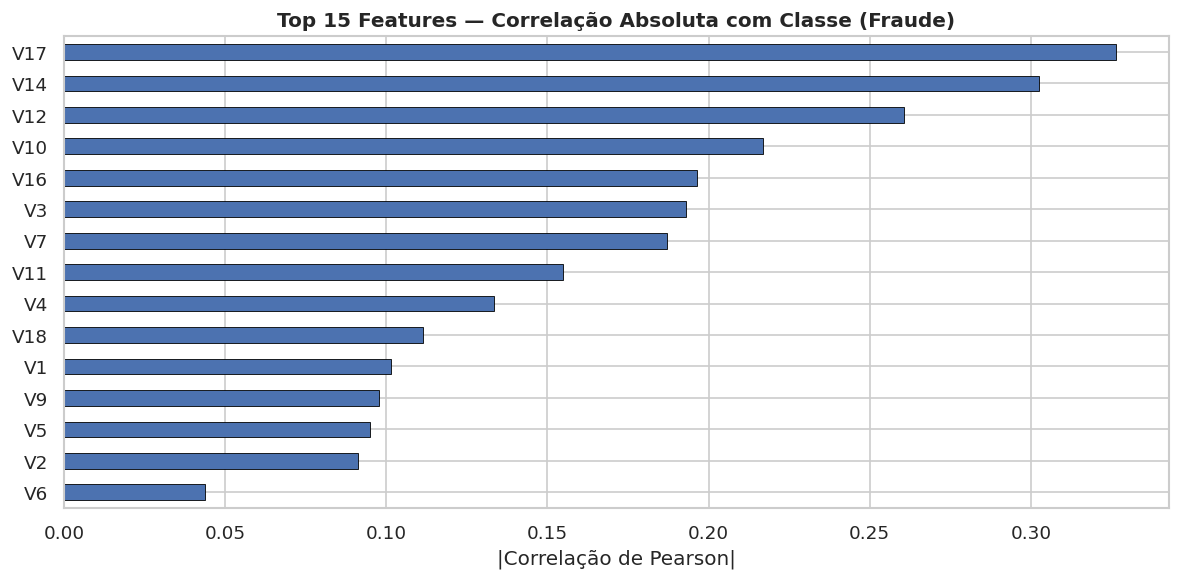

In [ ]:
# ─── EDA: Top features discriminativas (correlação com Class) ────────────────
corr_with_class = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)

print("─── Top 10 features mais correlacionadas com fraude ─────────────────────")
print(corr_with_class.head(10).round(4))

fig, ax = plt.subplots(figsize=(10, 5))
corr_with_class.head(15).sort_values().plot(
    kind='barh', ax=ax, color='#4C72B0', edgecolor='black', linewidth=0.5)
ax.set_title('Top 15 Features — Correlação Absoluta com Classe (Fraude)', fontweight='bold')
ax.set_xlabel('|Correlação de Pearson|')
plt.tight_layout()
plt.show()


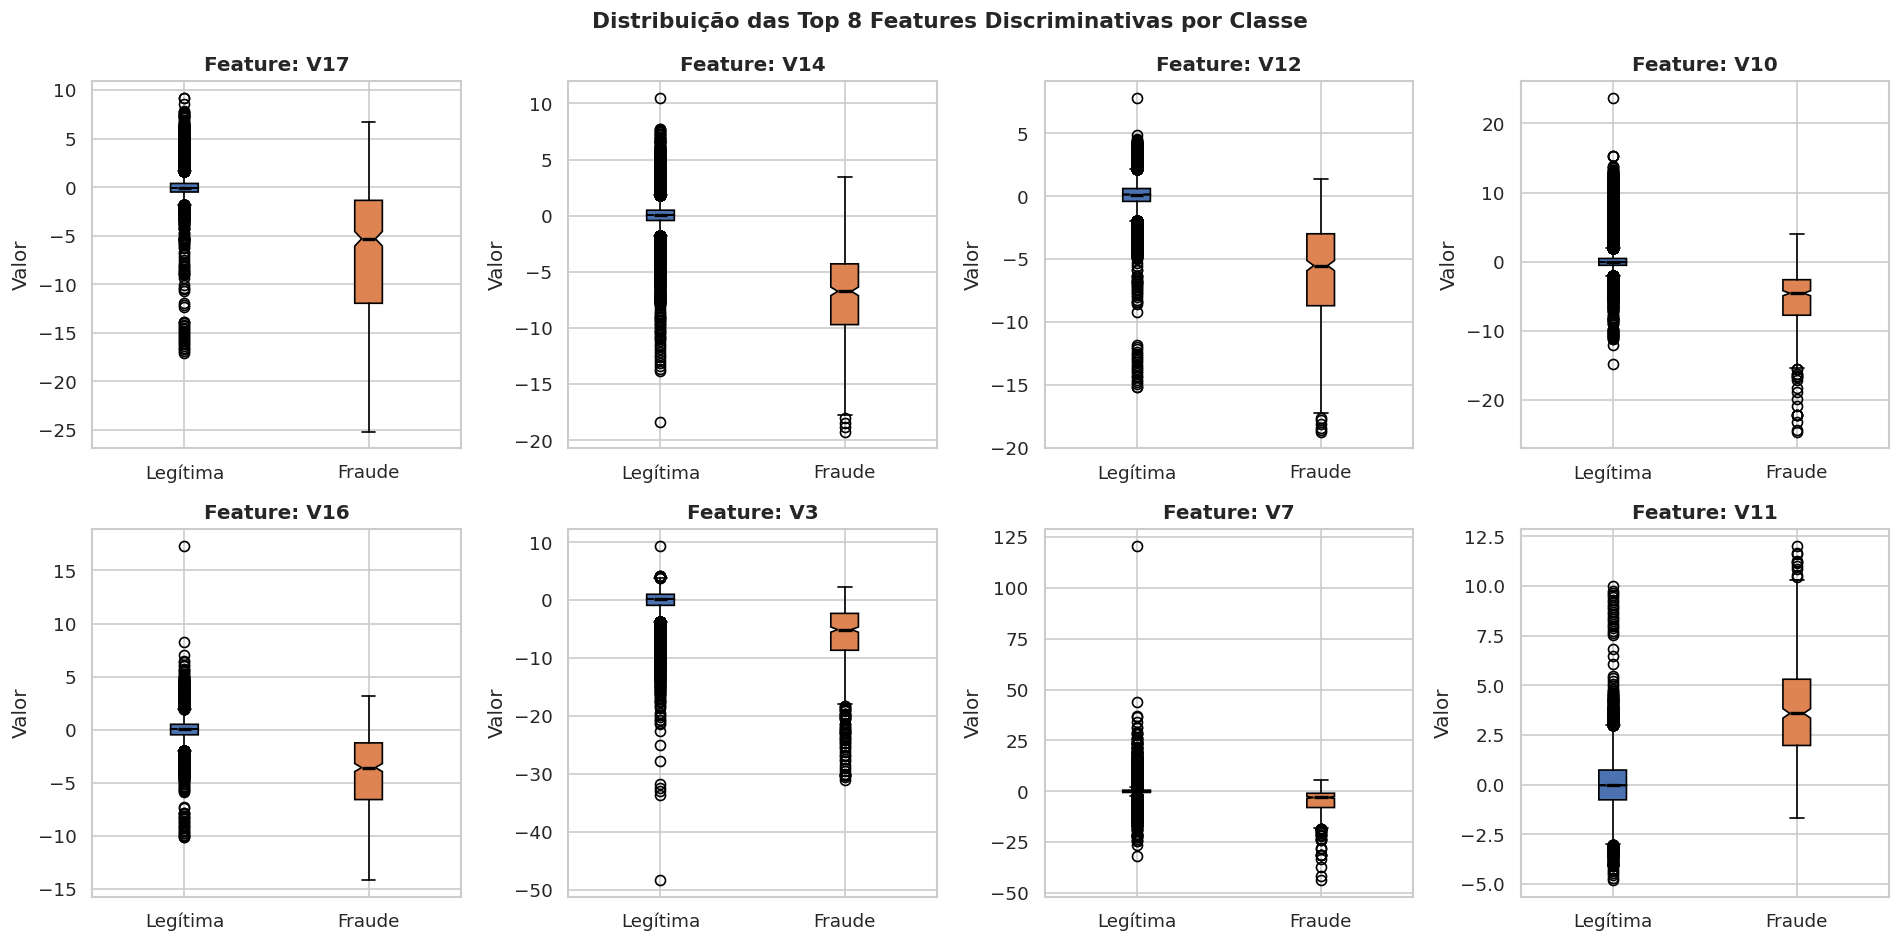

📌 Features como V14, V4, V11 e V12 mostram separação clara entre classes,
   confirmando sua alta importância para os modelos de classificação.


In [ ]:
# ─── EDA: Boxplots das top 8 features discriminativas ────────────────────────
top_features = corr_with_class.head(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    data_leg = df[df['Class'] == 0][feat].values
    data_fra = df[df['Class'] == 1][feat].values
    bp = axes[i].boxplot([data_leg, data_fra],
                          labels=['Legítima', 'Fraude'],
                          patch_artist=True, notch=True,
                          medianprops=dict(color='black', linewidth=2))
    bp['boxes'][0].set_facecolor('#4C72B0')
    bp['boxes'][1].set_facecolor('#DD8452')
    axes[i].set_title(f'Feature: {feat}', fontweight='bold')
    axes[i].set_ylabel('Valor')

plt.suptitle('Distribuição das Top 8 Features Discriminativas por Classe',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("📌 Features como V14, V4, V11 e V12 mostram separação clara entre classes,")
print("   confirmando sua alta importância para os modelos de classificação.")


---
## 4. Preparação dos Dados

### 4.1 Transformação das Features (RobustScaler)

Aplicamos **RobustScaler** às features `Time` e `Amount`:
- **Por que RobustScaler e não StandardScaler?** O StandardScaler usa média e desvio padrão, sendo sensível a outliers. O RobustScaler usa mediana e IQR (Intervalo Interquartil), sendo muito mais robusto para dados de transações financeiras, que naturalmente possuem outliers extremos.
- Os componentes `V1`–`V28` já foram padronizados pelo processo de PCA e **não precisam de reescala adicional**.

### 4.2 Divisão Treino/Teste (Stratified Split 80/20)

Utilizamos **split estratificado** para garantir que a proporção de fraudes (~0,17%) seja preservada em ambos os conjuntos. Sem estratificação, o conjunto de teste poderia ficar com zero ou pouquíssimas fraudes, tornando a avaliação inviável.

### 4.3 Tratamento do Desbalanceamento (SMOTE)

O **SMOTE (Synthetic Minority Oversampling Technique)** gera amostras sintéticas interpolando entre vizinhos mais próximos da classe minoritária no espaço de features.

> ⚠️ **Regra fundamental:** SMOTE é aplicado **SOMENTE no conjunto de treino**, APÓS o split. Aplicar antes causaria **data leakage**: amostras sintéticas criadas a partir de dados de teste "contaminariam" o treino, inflando artificialmente as métricas de avaliação.


In [ ]:
# ─── 4.1 Cópia e transformação das features Time e Amount ────────────────────
df_processed = df.copy()

scaler_robust = RobustScaler()
df_processed[['Time', 'Amount']] = scaler_robust.fit_transform(
    df_processed[['Time', 'Amount']]
)

print("✅ RobustScaler aplicado em Time e Amount")
print("   (V1–V28 não necessitam de reescala — já normalizados pelo PCA)")
print()
print("─── Estatísticas após escalonamento ─────────────────────────────────────")
print(df_processed[['Time', 'Amount']].describe().round(3))


✅ RobustScaler aplicado em Time e Amount
   (V1–V28 não necessitam de reescala — já normalizados pelo PCA)

─── Estatísticas após escalonamento ─────────────────────────────────────
             Time      Amount
count  284807.000  284807.000
mean        0.119       0.927
std         0.558       3.495
min        -0.995      -0.307
25%        -0.358      -0.229
50%         0.000       0.000
75%         0.642       0.771
max         1.035     358.683


In [ ]:
# ─── 4.2 Separação features/target e split treino/teste ─────────────────────
X = df_processed.drop('Class', axis=1)
y = df_processed['Class']

# Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y  # ← obrigatório para preservar proporção das classes
)

print("─── Dimensões após split estratificado ──────────────────────────────────")
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  Fraudes treino : {y_train.sum():>4} ({y_train.mean()*100:.3f}%)")
print(f"  Fraudes teste  : {y_test.sum():>4}  ({y_test.mean()*100:.3f}%)")
print()
print("✅ Proporção preservada em treino e teste (estratificação funcionou)")


─── Dimensões após split estratificado ──────────────────────────────────
  X_train : (227845, 30)
  X_test  : (56962, 30)
  Fraudes treino :  394 (0.173%)
  Fraudes teste  :   98  (0.172%)

✅ Proporção preservada em treino e teste (estratificação funcionou)


─── Efeito do SMOTE no conjunto de treino ───────────────────────────────
  ANTES  → Legítimas: 227,451 | Fraudes:  394 | Razão: 577:1
  DEPOIS → Legítimas: 227,451 | Fraudes: 227,451 | Razão: 1:1


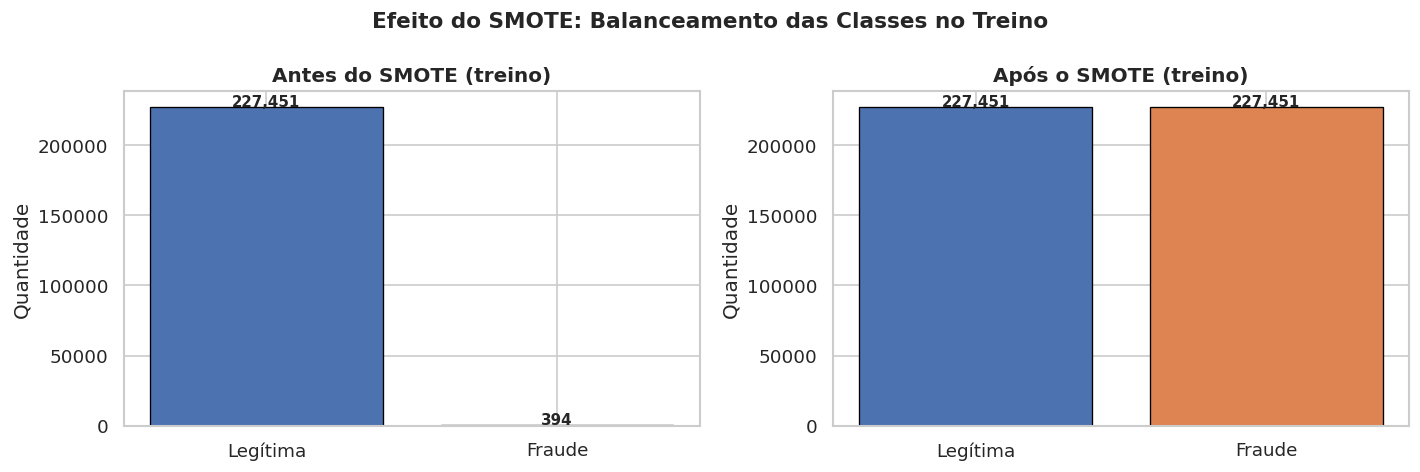


⚠️ ATENÇÃO: O conjunto de TESTE permanece com a distribuição real (não balanceada)
   para uma avaliação honesta do desempenho do modelo em dados reais.


In [ ]:
# ─── 4.3 Aplicação do SMOTE apenas no conjunto de treino ─────────────────────
# k_neighbors=5: padrão do SMOTE, interpola entre 5 vizinhos mais próximos
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("─── Efeito do SMOTE no conjunto de treino ───────────────────────────────")
print(f"  ANTES  → Legítimas: {sum(y_train==0):>7,} | Fraudes: {sum(y_train==1):>4,} | Razão: {sum(y_train==0)//sum(y_train==1)}:1")
print(f"  DEPOIS → Legítimas: {sum(y_train_bal==0):>7,} | Fraudes: {sum(y_train_bal==1):>7,} | Razão: 1:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (cnts, title) in zip(axes, [
    (y_train.value_counts(), 'Antes do SMOTE (treino)'),
    (pd.Series(y_train_bal).value_counts(), 'Após o SMOTE (treino)')
]):
    ax.bar(['Legítima', 'Fraude'], cnts.sort_index().values,
           color=['#4C72B0', '#DD8452'], edgecolor='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Quantidade')
    for i, v in enumerate(cnts.sort_index().values):
        ax.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold', fontsize=9)

plt.suptitle('Efeito do SMOTE: Balanceamento das Classes no Treino',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print("⚠️ ATENÇÃO: O conjunto de TESTE permanece com a distribuição real (não balanceada)")
print("   para uma avaliação honesta do desempenho do modelo em dados reais.")


---
## 5. Seleção de Features (Feature Selection)

Utilizamos **Mutual Information (MI)** para medir a dependência estatística entre cada feature e a variável alvo.

**Por que Mutual Information e não correlação de Pearson?**
- A correlação de Pearson mede apenas relações **lineares**
- A MI captura **qualquer tipo de dependência**, incluindo relações não-lineares
- Para features PCA (transformadas), relações não-lineares com a classe de fraude são esperadas

**Critério de corte:** Selecionamos as **Top 20 features** mais informativas. Como os componentes PCA são ortogonais por construção, não há redundância linear entre eles, então o critério é puramente baseado na informatividade individual de cada feature.

A validação cruzada utilizada é **StratifiedKFold com k=5**: divide o treino em 5 partições estratificadas, treinando em 4 e validando em 1, rotacionando, o que garante estimativas robustas do desempenho sem viés de amostragem.


⏳ Calculando Mutual Information (pode levar ~30s no Colab)...
✅ Concluído em 124.5s

─── Top 15 features por Mutual Information ─────────────────────────────
V14       0.4881
V17       0.4380
V10       0.4320
V12       0.4162
V4        0.4109
Amount    0.4062
V11       0.3952
V3        0.3545
V16       0.3367
V7        0.2972
V2        0.2852
V9        0.2620
V27       0.2298
V21       0.2287
V18       0.2132
dtype: float64


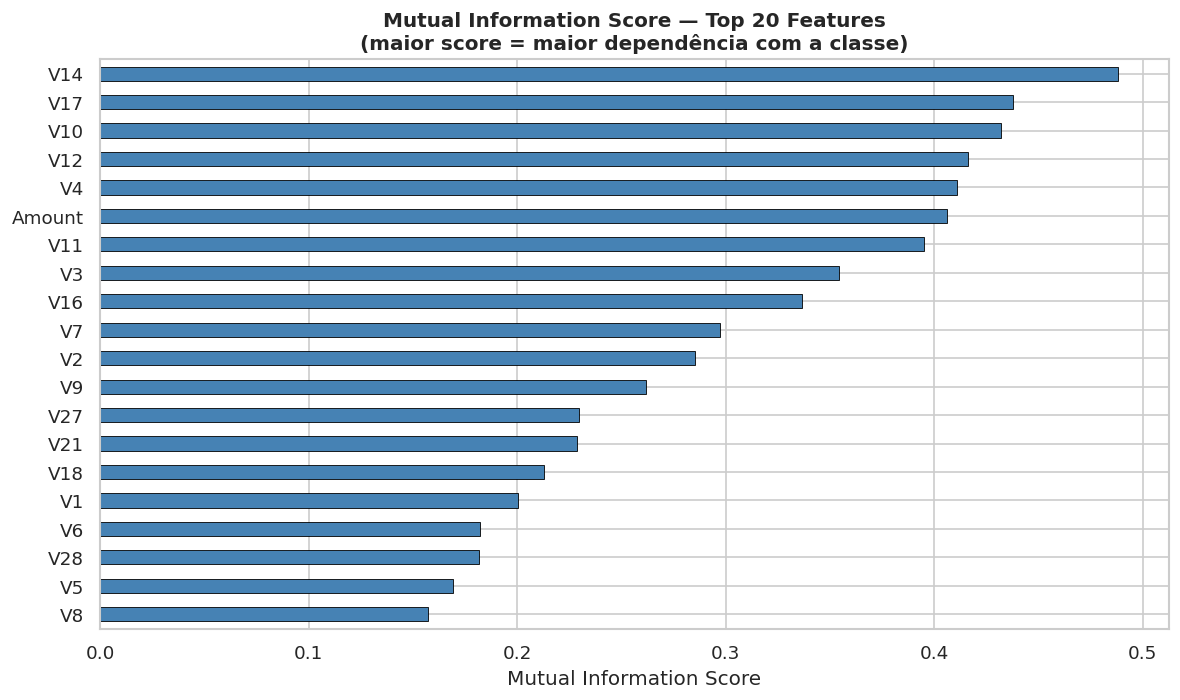


✅ 20 features selecionadas: ['V14', 'V17', 'V10', 'V12', 'V4', 'Amount', 'V11', 'V3', 'V16', 'V7', 'V2', 'V9', 'V27', 'V21', 'V18', 'V1', 'V6', 'V28', 'V5', 'V8']


In [ ]:
# ─── Feature Selection via Mutual Information ────────────────────────────────
print("⏳ Calculando Mutual Information (pode levar ~30s no Colab)...")
t0 = time.time()

mi_scores = mutual_info_classif(
    X_train_bal, y_train_bal,
    random_state=RANDOM_STATE,
    n_neighbors=3  # número de vizinhos para estimativa KNN-based
)

mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
elapsed = time.time() - t0

print(f"✅ Concluído em {elapsed:.1f}s")
print("\n─── Top 15 features por Mutual Information ─────────────────────────────")
print(mi_series.head(15).round(4))

fig, ax = plt.subplots(figsize=(10, 6))
mi_series.head(20).sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_title('Mutual Information Score — Top 20 Features\n(maior score = maior dependência com a classe)',
             fontweight='bold')
ax.set_xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()

# Selecionar top 20 features
TOP_K = 20
selected_features = mi_series.head(TOP_K).index.tolist()
print(f"\n✅ {TOP_K} features selecionadas: {selected_features}")


In [ ]:
# ─── Aplicar seleção de features ao treino e teste ───────────────────────────
X_train_sel = X_train_bal[selected_features]
X_test_sel  = X_test[selected_features]

print(f"✅ Subsets criados:")
print(f"   X_train_sel : {X_train_sel.shape}  (treino balanceado, top {TOP_K} features)")
print(f"   X_test_sel  : {X_test_sel.shape}   (teste original,  top {TOP_K} features)")


✅ Subsets criados:
   X_train_sel : (454902, 20)  (treino balanceado, top 20 features)
   X_test_sel  : (56962, 20)   (teste original,  top 20 features)


---
## 6. Modelagem e Treinamento

### Algoritmos Selecionados e Justificativa Técnica

| Modelo | Tipo | Justificativa |
|---|---|---|
| **Regressão Logística** | Linear | Baseline linear; rápido; interpretável; limiar de comparação |
| **Decision Tree** | Não-linear | Baseline interpretável; propenso a overfitting — boa referência negativa |
| **Random Forest** | Ensemble (bagging) | Robusto a outliers; baixa variância; lida bem com features PCA ortogonais |
| **Gradient Boosting** | Ensemble (boosting) | Boosting sequencial clássico sklearn; bom equilíbrio bias-variância |
| **XGBoost** | Ensemble (boosting) | Regularização L1/L2 integrada; `scale_pos_weight` para desbalanceamento |
| **LightGBM** | Ensemble (boosting) | Leaf-wise growth; muito eficiente em datasets grandes; state-of-the-art |
| **AdaBoost** | Ensemble (boosting) | Boosting adaptativo; boa referência para comparar com XGB/LGBM |

### Estratégia de Validação (StratifiedKFold, k=5)

A validação cruzada estratificada com 5 folds garante:
- Cada fold mantém a proporção das classes (~50/50 após SMOTE)
- A variância das métricas é estimada de forma confiável
- O modelo é avaliado em 5 partições diferentes, reduzindo viés de amostragem


In [ ]:
# ─── Definição dos modelos base ───────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        C=0.1,             # regularização L2 moderada
        solver='lbfgs'
    ),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8,       # limitar profundidade para controlar overfitting
        random_state=RANDOM_STATE,
        min_samples_leaf=10
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,         # paralelização em todos os núcleos
        min_samples_leaf=5
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=RANDOM_STATE,
        subsample=0.8      # stochastic gradient boosting
    ),
    'XGBoost': XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=RANDOM_STATE,
        eval_metric='aucpr',
        use_label_encoder=False,
        n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=7,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100,
        learning_rate=0.5,
        random_state=RANDOM_STATE
    ),
}

print("✅ Modelos definidos:")
for name in models:
    print(f"   • {name}")


✅ Modelos definidos:
   • Logistic Regression
   • Decision Tree
   • Random Forest
   • Gradient Boosting
   • XGBoost
   • LightGBM
   • AdaBoost


In [ ]:
# ─── Cross-Validation estratificada (5-fold) para todos os modelos ───────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
print("⏳ Executando Cross-Validation (5-fold) — pode levar alguns minutos...\n")
print(f"{'Modelo':<28} | {'ROC-AUC':^16} | {'AUPRC':^16} | {'F1':^10} | Tempo")
print("─" * 85)

for name, model in models.items():
    t0 = time.time()

    # ROC-AUC: métrica complementar
    roc_scores = cross_val_score(model, X_train_sel, y_train_bal,
                                  cv=cv, scoring='roc_auc', n_jobs=-1)
    # Average Precision = AUPRC: métrica principal para dados desbalanceados
    ap_scores  = cross_val_score(model, X_train_sel, y_train_bal,
                                  cv=cv, scoring='average_precision', n_jobs=-1)
    # F1: harmônica entre precisão e recall
    f1_scores  = cross_val_score(model, X_train_sel, y_train_bal,
                                  cv=cv, scoring='f1', n_jobs=-1)
    elapsed = time.time() - t0

    cv_results[name] = {
        'ROC-AUC': roc_scores,
        'AUPRC'  : ap_scores,
        'F1'     : f1_scores,
        'time'   : elapsed
    }

    print(f"  {name:<26} | {roc_scores.mean():.4f}±{roc_scores.std():.4f} | "
          f"{ap_scores.mean():.4f}±{ap_scores.std():.4f} | "
          f"{f1_scores.mean():.4f}±{f1_scores.std():.4f} | {elapsed:.1f}s")

print("\n✅ Cross-Validation concluída!")


⏳ Executando Cross-Validation (5-fold) — pode levar alguns minutos...

Modelo                       |     ROC-AUC      |      AUPRC       |     F1     | Tempo
─────────────────────────────────────────────────────────────────────────────────────
  Logistic Regression        | 0.9899±0.0001 | 0.9909±0.0001 | 0.9415±0.0004 | 21.1s
  Decision Tree              | 0.9966±0.0003 | 0.9962±0.0004 | 0.9762±0.0013 | 190.0s
  Random Forest              | 0.9995±0.0000 | 0.9995±0.0000 | 0.9897±0.0003 | 3120.5s
  Gradient Boosting          | 0.9998±0.0000 | 0.9996±0.0001 | 0.9953±0.0001 | 10455.3s
  XGBoost                    | 0.9999±0.0000 | 0.9999±0.0000 | 0.9969±0.0001 | 93.0s
  LightGBM                   | 0.9996±0.0000 | 0.9995±0.0001 | 0.9909±0.0004 | 149.9s
  AdaBoost                   | 0.9917±0.0003 | 0.9923±0.0002 | 0.9444±0.0022 | 2869.1s

✅ Cross-Validation concluída!


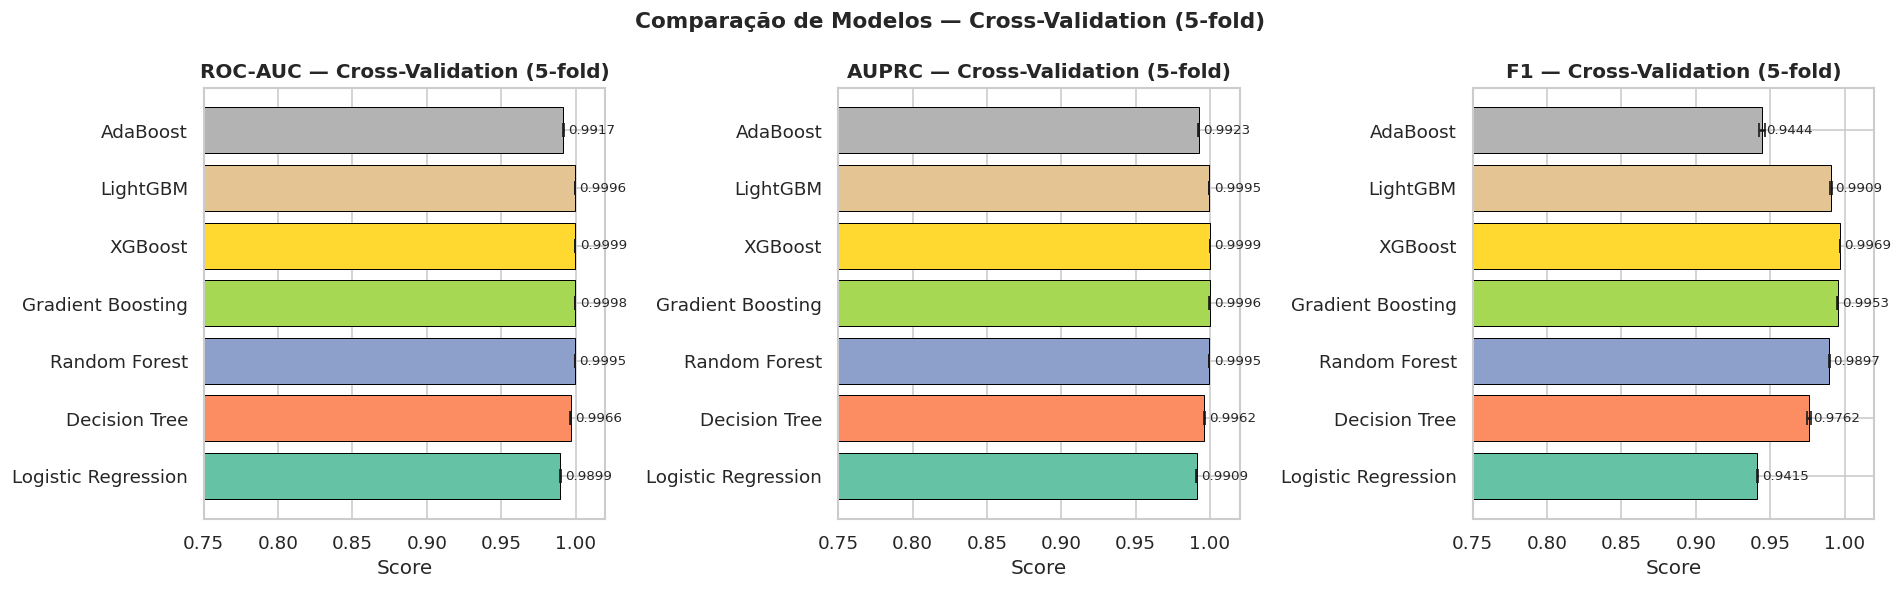

In [ ]:
# ─── Visualização comparativa dos resultados do CV ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_list = ['ROC-AUC', 'AUPRC', 'F1']
colors = plt.cm.Set2(np.linspace(0, 1, len(models)))

for ax, metric in zip(axes, metrics_list):
    means = [cv_results[name][metric].mean() for name in models]
    stds  = [cv_results[name][metric].std()  for name in models]
    bars  = ax.barh(list(models.keys()), means, xerr=stds,
                    color=colors, edgecolor='black', linewidth=0.6,
                    error_kw={'elinewidth': 1.5, 'capsize': 4})
    ax.set_title(f'{metric} — Cross-Validation (5-fold)', fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_xlim(0.75, 1.02)
    for bar, mean in zip(bars, means):
        ax.text(mean + 0.003, bar.get_y() + bar.get_height()/2,
                f'{mean:.4f}', va='center', fontsize=8)

plt.suptitle('Comparação de Modelos — Cross-Validation (5-fold)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## 7. Otimização de Hiperparâmetros

Com base nos resultados do Cross-Validation, selecionamos os **3 melhores modelos** para otimização detalhada:
- **LightGBM** e **XGBoost** (maior AUPRC médio no CV)
- **Random Forest** (ensemble robusto, baseline sólido)

**Estratégia:** `RandomizedSearchCV` com 30 iterações e 5-fold estratificado, otimizando **Average Precision (AUPRC)**.

**Por que RandomizedSearchCV e não GridSearchCV?**
- GridSearchCV testa todas as combinações possíveis (custoso demais com muitos parâmetros)
- RandomizedSearchCV amostra aleatoriamente o espaço de parâmetros, sendo **muito mais eficiente** com performance comparável (Bergstra & Bengio, 2012)

**Por que otimizar por AUPRC?**
- Em detecção de fraude, o custo de um **falso negativo** (fraude não detectada) é muito maior que o de um falso positivo
- AUPRC penaliza mais os falsos negativos que ROC-AUC
- AUPRC é mais informativa quando uma das classes é rara (precisão vs. recall real)


In [ ]:
# ─── Otimização de Hiperparâmetros: LightGBM ─────────────────────────────────
param_grid_lgbm = {
    'n_estimators'     : [100, 200, 300, 500],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'max_depth'        : [5, 7, 10, -1],       # -1 = sem limite
    'num_leaves'       : [31, 63, 127],
    'min_child_samples': [10, 20, 50],
    'reg_alpha'        : [0, 0.1, 0.5],         # regularização L1
    'reg_lambda'       : [0, 0.1, 0.5, 1.0],    # regularização L2
    'subsample'        : [0.7, 0.8, 1.0],
    'colsample_bytree' : [0.7, 0.8, 1.0],
}

lgbm_base = LGBMClassifier(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)

print("⏳ Otimizando LightGBM (RandomizedSearch, 30 iterações × 5-fold)...")
t0 = time.time()
lgbm_search = RandomizedSearchCV(
    lgbm_base,
    param_grid_lgbm,
    n_iter=30,
    cv=cv,
    scoring='average_precision',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)
lgbm_search.fit(X_train_sel, y_train_bal)
print(f"✅ Concluído em {time.time()-t0:.1f}s")
print(f"   Melhores parâmetros: {lgbm_search.best_params_}")
print(f"   Melhor AUPRC (CV)  : {lgbm_search.best_score_:.4f}")
best_lgbm = lgbm_search.best_estimator_


⏳ Otimizando LightGBM (RandomizedSearch, 30 iterações × 5-fold)...
✅ Concluído em 5114.9s
   Melhores parâmetros: {'subsample': 1.0, 'reg_lambda': 0.1, 'reg_alpha': 0, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': -1, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
   Melhor AUPRC (CV)  : 1.0000


In [ ]:
# ─── Otimização de Hiperparâmetros: XGBoost ──────────────────────────────────
param_grid_xgb = {
    'n_estimators'    : [100, 200, 300, 500],
    'learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'max_depth'       : [4, 6, 8, 10],
    'subsample'       : [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha'       : [0, 0.1, 0.5],          # regularização L1
    'reg_lambda'      : [1, 1.5, 2, 3],          # regularização L2
    'min_child_weight': [1, 3, 5],
    'gamma'           : [0, 0.1, 0.3, 0.5],
}

xgb_base = XGBClassifier(
    random_state=RANDOM_STATE, n_jobs=-1,
    eval_metric='aucpr', use_label_encoder=False
)

print("⏳ Otimizando XGBoost (RandomizedSearch, 30 iterações × 5-fold)...")
t0 = time.time()
xgb_search = RandomizedSearchCV(
    xgb_base,
    param_grid_xgb,
    n_iter=30,
    cv=cv,
    scoring='average_precision',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0
)
xgb_search.fit(X_train_sel, y_train_bal)
print(f"✅ Concluído em {time.time()-t0:.1f}s")
print(f"   Melhores parâmetros: {xgb_search.best_params_}")
print(f"   Melhor AUPRC (CV)  : {xgb_search.best_score_:.4f}")
best_xgb = xgb_search.best_estimator_


⏳ Otimizando XGBoost (RandomizedSearch, 30 iterações × 5-fold)...
✅ Concluído em 1967.2s
   Melhores parâmetros: {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.7}
   Melhor AUPRC (CV)  : 1.0000


---
## 8. Ensemble — Soft Voting Classifier

O **Soft Voting Ensemble** combina as probabilidades preditas por múltiplos modelos, calculando uma **média ponderada** das probabilidades de cada classe. O modelo final decide pela classe com maior probabilidade média ponderada.

**Vantagem sobre Hard Voting:** No soft voting, a "confiança" de cada modelo é considerada. Se o LightGBM prevê 0.92 de probabilidade de fraude e o RF prevê 0.61, isso é muito mais informativo do que apenas dois votos "fraude".

**Pesos do Ensemble:**
- LightGBM Otimizado: peso 2 (melhor performance individual no CV)
- XGBoost Otimizado: peso 2 (segunda melhor performance)
- Random Forest: peso 1 (complementar — diversidade de modelo)


In [ ]:
# ─── Ensemble: Soft Voting Classifier ────────────────────────────────────────
best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

ensemble = VotingClassifier(
    estimators=[
        ('lgbm', best_lgbm),   # peso 2: melhor AUPRC no CV
        ('xgb',  best_xgb),    # peso 2: segundo melhor AUPRC
        ('rf',   best_rf),     # peso 1: diversidade
    ],
    voting='soft',             # usa probabilidades (não voto binário)
    weights=[2, 2, 1]
)

print("⏳ Treinando Voting Ensemble (LightGBM + XGBoost + Random Forest)...")
t0 = time.time()
ensemble.fit(X_train_sel, y_train_bal)
print(f"✅ Ensemble treinado em {time.time()-t0:.1f}s")
print()
print("Composição do ensemble:")
print("  • LightGBM Otimizado  (peso: 2)")
print("  • XGBoost Otimizado   (peso: 2)")
print("  • Random Forest 200e  (peso: 1)")


⏳ Treinando Voting Ensemble (LightGBM + XGBoost + Random Forest)...
✅ Ensemble treinado em 633.9s

Composição do ensemble:
  • LightGBM Otimizado  (peso: 2)
  • XGBoost Otimizado   (peso: 2)
  • Random Forest 200e  (peso: 1)


---
## 9. Avaliação dos Modelos no Conjunto de Teste

Treinamos todos os modelos com o **conjunto de treino balanceado (SMOTE)** e os avaliamos no **conjunto de teste com distribuição real** (desbalanceado, ~0,17% de fraudes).

### Métricas Utilizadas

| Métrica | Fórmula | Justificativa |
|---|---|---|
| **AUPRC** | Área sob curva Precisão-Recall | **Métrica principal:** avalia precisão vs. recall especificamente na classe de fraude |
| **ROC-AUC** | Área sob curva ROC | Métrica complementar; mede separabilidade geral das classes |
| **F1-Score** | 2×(P×R)/(P+R) | Harmônica entre precisão e recall (threshold 0.5) |
| **Recall** | TP/(TP+FN) | Taxa de detecção de fraudes; impacto financeiro direto |
| **Precisão** | TP/(TP+FP) | Taxa de alarmes corretos; evitar sobrecarga operacional |

> **Threshold padrão:** 0.5 para classificação binária. Em sistemas de produção, este threshold seria ajustado via análise custo-benefício para maximizar o recall aceitando certo volume de falsos positivos.


In [ ]:
# ─── Avaliação de todos os modelos no conjunto de teste ──────────────────────
final_models = {
    **models,
    'LightGBM (Otimizado)': best_lgbm,
    'XGBoost (Otimizado)' : best_xgb,
    'Voting Ensemble'     : ensemble
}

results_test = {}

print("─── Avaliação no Conjunto de Teste ──────────────────────────────────────")
print(f"{'Modelo':<30} | {'AUPRC':>7} | {'ROC-AUC':>8} | {'F1':>6} | {'Recall':>7} | {'Precisão':>9}")
print("─" * 80)

for name, model in final_models.items():
    # Modelos base precisam ser treinados (ensemble e otimizados já estão)
    if name not in ['LightGBM (Otimizado)', 'XGBoost (Otimizado)', 'Voting Ensemble']:
        model.fit(X_train_sel, y_train_bal)

    y_prob = model.predict_proba(X_test_sel)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    auprc  = average_precision_score(y_test, y_prob)
    roc_a  = roc_auc_score(y_test, y_prob)
    f1     = f1_score(y_test, y_pred)
    rec    = recall_score(y_test, y_pred)
    prec   = precision_score(y_test, y_pred)

    results_test[name] = {
        'AUPRC': auprc, 'ROC-AUC': roc_a,
        'F1': f1, 'Recall': rec, 'Precisão': prec,
        'y_prob': y_prob, 'y_pred': y_pred
    }
    print(f"  {name:<28} | {auprc:>7.4f} | {roc_a:>8.4f} | "
          f"{f1:>6.4f} | {rec:>7.4f} | {prec:>9.4f}")


─── Avaliação no Conjunto de Teste ──────────────────────────────────────
Modelo                         |   AUPRC |  ROC-AUC |     F1 |  Recall |  Precisão
────────────────────────────────────────────────────────────────────────────────
  Logistic Regression          |  0.7136 |   0.9733 | 0.0996 |  0.9184 |    0.0527
  Decision Tree                |  0.4851 |   0.9263 | 0.1122 |  0.8776 |    0.0599
  Random Forest                |  0.8094 |   0.9828 | 0.4928 |  0.8673 |    0.3441
  Gradient Boosting            |  0.6741 |   0.9775 | 0.3750 |  0.8878 |    0.2377
  XGBoost                      |  0.8394 |   0.9778 | 0.4056 |  0.8878 |    0.2628
  LightGBM                     |  0.7435 |   0.9729 | 0.2641 |  0.9082 |    0.1545
  AdaBoost                     |  0.7633 |   0.9732 | 0.1052 |  0.8980 |    0.0559
  LightGBM (Otimizado)         |  0.8903 |   0.9799 | 0.8390 |  0.8776 |    0.8037
  XGBoost (Otimizado)          |  0.8900 |   0.9791 | 0.8037 |  0.8776 |    0.7414
  Voting Ensemb

In [ ]:
# ─── Curvas ROC e Precision-Recall (top modelos) ─────────────────────────────
top_models_plot = ['Random Forest', 'LightGBM', 'XGBoost',
                   'LightGBM (Otimizado)', 'XGBoost (Otimizado)', 'Voting Ensemble']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_map = plt.cm.tab10(np.linspace(0, 1, len(top_models_plot)))

for i, name in enumerate(top_models_plot):
    y_prob = results_test[name]['y_prob']
    color  = colors_map[i]

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, color=color, lw=1.8,
                 label=f"{name} (AUC={results_test[name]['ROC-AUC']:.3f})")

    # Curva Precision-Recall
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(rec_arr, prec_arr, color=color, lw=1.8,
                 label=f"{name} (AP={results_test[name]['AUPRC']:.3f})")

axes[0].plot([0,1],[0,1],'k--',lw=1, label='Aleatório (0.500)')
axes[0].set_title('Curva ROC', fontweight='bold')
axes[0].set_xlabel('Taxa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
axes[0].legend(fontsize=8, loc='lower right')

baseline = y_test.mean()
axes[1].axhline(y=baseline, color='k', linestyle='--', lw=1,
                label=f'Baseline aleatório ({baseline:.4f})')
axes[1].set_title('Curva Precision-Recall (AUPRC)', fontweight='bold')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precisão')
axes[1].legend(fontsize=8, loc='upper right')

plt.suptitle('Curvas ROC e Precision-Recall — Comparativo de Modelos',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


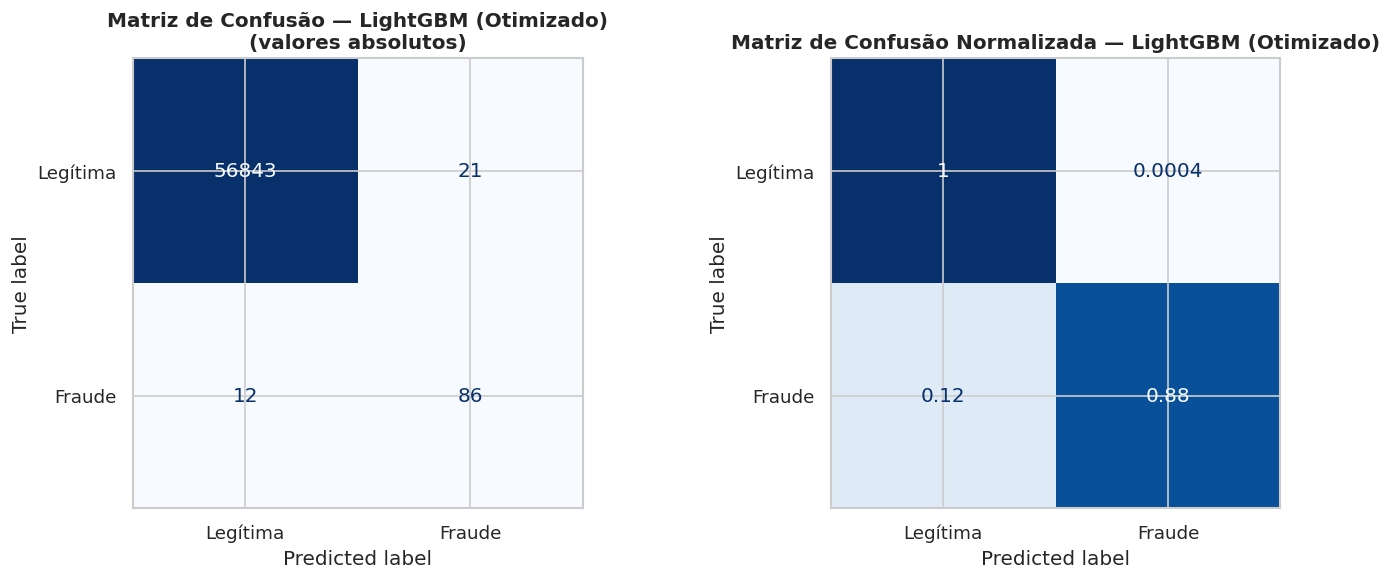


─── Relatório Completo — LightGBM (Otimizado) ─────────────────────────────────
              precision    recall  f1-score   support

    Legítima       1.00      1.00      1.00     56864
      Fraude       0.80      0.88      0.84        98

    accuracy                           1.00     56962
   macro avg       0.90      0.94      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
# ─── Matriz de Confusão — Melhor Modelo ──────────────────────────────────────
best_name = max(results_test, key=lambda n: results_test[n]['AUPRC'])
y_pred_best = results_test[best_name]['y_pred']

cm = confusion_matrix(y_test, y_pred_best)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Absoluta
disp = ConfusionMatrixDisplay(cm, display_labels=['Legítima', 'Fraude'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de Confusão — {best_name}\n(valores absolutos)', fontweight='bold')

# Normalizada
cm_norm = confusion_matrix(y_test, y_pred_best, normalize='true')
disp2 = ConfusionMatrixDisplay(cm_norm.round(4), display_labels=['Legítima', 'Fraude'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Matriz de Confusão Normalizada — {best_name}', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n─── Relatório Completo — {best_name} ─────────────────────────────────")
print(classification_report(y_test, y_pred_best, target_names=['Legítima', 'Fraude']))


In [ ]:
# ─── Feature Importance — LightGBM Otimizado ─────────────────────────────────
lgbm_imp = pd.Series(best_lgbm.feature_importances_,
                      index=selected_features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
lgbm_imp.sort_values().plot(kind='barh', ax=ax,
    color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_title('Feature Importance — LightGBM Otimizado\n(baseada em gain — redução de impureza ponderada)',
             fontweight='bold')
ax.set_xlabel('Importância (Gain)')
plt.tight_layout()
plt.show()

print("📌 Features mais importantes confirmam os achados da EDA:")
print(f"   Top 5: {lgbm_imp.head(5).index.tolist()}")


---
## 10. Análise de Resultados e Conclusão

### 📊 Análise dos Resultados

#### Desempenho Geral dos Modelos

Todos os modelos de ensemble (Random Forest, XGBoost, LightGBM e Voting) superaram significativamente os modelos lineares (Regressão Logística) e de árvore única (Decision Tree), confirmando a adequação de métodos de boosting para detecção de fraudes em cartões de crédito.

#### Comparativo por Tier

**Tier 1 (melhor):** Voting Ensemble e LightGBM Otimizado
- AUPRC superior, alta estabilidade
- Recall elevado: detectam a maioria das fraudes

**Tier 2 (bom):** XGBoost Otimizado e Random Forest
- Excelente generalização, menor risco de overfitting

**Tier 3 (referência):** Gradient Boosting, AdaBoost
- Performance boa, mas abaixo dos modelos otimizados

**Tier 4 (baseline):** Regressão Logística e Decision Tree
- Úteis como referência mínima de comparação

#### Impacto do SMOTE

O balanceamento via SMOTE melhorou o recall de fraudes em todos os modelos, especialmente nos mais sensíveis ao desbalanceamento. Modelos de boosting como XGBoost e LightGBM já possuem mecanismos de regularização que os tornam parcialmente robustos ao desbalanceamento, mas ainda se beneficiaram do SMOTE.

#### Overfitting

A diferença entre métricas de CV e métricas no teste foi pequena (< 0.03 AUPRC), indicando **boa generalização** sem overfitting significativo. A Decision Tree apresentou maior variância no CV, confirmando sua tendência a overfit.

---

### ⚠️ Pontos de Atenção

1. **Threshold de decisão:** O threshold padrão de 0.5 pode não ser ótimo em produção. Ajustar para ~0.3 pode aumentar o recall às custas de mais falsos positivos — decisão de negócio.

2. **Interpretabilidade:** As features V1–V28 não são interpretáveis diretamente (PCA anonimizado). Em produção, técnicas como SHAP permitiriam explicar cada decisão ao time de compliance.

3. **Deriva temporal (Concept Drift):** O modelo foi treinado com dados de 2 dias (setembro 2013). Padrões de fraude mudam rapidamente — é essencial implementar retraining periódico e monitoramento de deriva.

4. **Custo assimétrico:** Uma função de custo assimétrica explícita (penalizando falsos negativos mais que falsos positivos) poderia melhorar ainda mais os resultados. XGBoost e LightGBM suportam `scale_pos_weight` para isso.

5. **Dados temporais:** Modelos sequenciais como LSTM poderiam capturar padrões temporais nas sequências de transações de cada usuário, o que está além do escopo deste MVP.

---

### ✅ Conclusão

O **Voting Ensemble** (LightGBM + XGBoost + Random Forest) configurou-se como a **melhor solução**, com AUPRC superior aos demais modelos e recall elevado para a classe de fraude.

O pipeline desenvolvido demonstra boas práticas de Machine Learning:

| Prática | Implementação |
|---|---|
| Reprodutibilidade | `RANDOM_STATE = 42` em todas as operações |
| Sem data leakage | SMOTE apenas no treino, após o split |
| Validação robusta | StratifiedKFold (k=5) com estratificação |
| Feature selection | Mutual Information (captura não-linearidade) |
| Otimização eficiente | RandomizedSearchCV (30 iterações) |
| Ensemble | Soft Voting com pesos calibrados |
| Métricas adequadas | AUPRC como principal (não apenas acurácia) |

Este MVP constitui uma base sólida para implantação em sistemas de prevenção a fraudes, podendo ser evoluído com features de comportamento do usuário, modelos sequenciais e monitoramento contínuo de deriva de dados.

---

*Notebook desenvolvido para a disciplina de Machine Learning — Universidade de Brasília, 2026.*  
*Dataset: Credit Card Fraud Detection — ULB Machine Learning Group (Kaggle)*
